<a href="https://colab.research.google.com/github/changyunyeong/MachineLearning_2026_01/blob/main/ML%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_4%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1_Classification(2)_%E1%84%83%E1%85%A1%E1%86%B8%E1%84%8B%E1%85%A1%E1%86%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 실습 4주차

### ■ **Classification Problem**
* **input**: $d$-차원 벡터 $\bf{x}\in \mathbb{R}^d$
* **output**: $K$개의 discrete 클래스 중 하나 $t \in \{c_1, c_2, ... ,c_K\}$

**[목표]**
1. 입력 변수로부터 **범주형 반응변수(class label)를 예측**하는 것
  * **Logistic Regression**: 입력 변수의 선형결합을 logit에 연결해 각 클래스에 속할 확률을 추정
  * **Naive Bayes**: 각 클래스에 대한 posterior probability를 계산하고, 가장 posterior가 큰 클래스로 label 예측
  * **k-NN**: 새로운 데이터와 가까운 $k$개의 이웃을 찾고, 그 이웃들의 label을 바탕으로 label 예측

2. 입력 공간을 여러 decision region으로 나누는 **decision boundary**를 찾는 것
  * 학습 데이터 $\mathcal{D}=\{(x_i, t_i)\}^n_{i=1}$로부터 모델 $f$를 학습
  * $\hat{t}= f(\bf{x})$를 예측
  * 클래스 수에 따라 구분
    * $K=2$: binary classification
    * $K>2$: multi-class classification


In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

---

# **Part 1. Discriminant Analysis**



### ■ **Fisher’s Linear Discriminant Analysis**
* **Binary Linear Discriminant Analysis**
  1. 입력 벡터를 일차원으로 projection
    $$
    \boxed{f(\bf{x}) = \bf{w}^T \bf{x}+\mathit{w_0}}
    $$

    * $\bf{w}$: 각 feature에 곱해지는 weight vector
    * $w_0$: 상수항 bias
  2. $f(\bf{x})$의 부호나 크기에 따라 class 결정
    * **decision surface**: $f(\bf{x})=\bf{w}^T \bf{x}+\mathit{w_0}=\rm{0}$을 만족하는 점들의 집합
      * $\bf{w}$: 경계의 방향
      * $w_0$: 경계의 위치 (threshold)

  > Fisher LDA의 기본 아이디어 ⇒ 1차원으로 잘 투영하자
  >  * (1) 좋은 방향 $\bf{w}$를 찾아서 데이터를 잘 투영하고
  >  * (2) 그 위에서 threshold $w_0$로 분류한다
  >  * 두 클래스 $\mathcal{C}_0$, $\mathcal{C}_1$의 평균이 멀수록 좋은 분류

* **Fisher criterion**
  * 클래스 평균 차이는 좋은 기준이 아님 ($\bf{w}$의 크기를 무한히 키우기만 해도 평균 차이가 커짐)
  * **클래스 간 분리(between-class scatter)** 와 **클래스 내부 분산(within-class scatter)** 를 함께 고려해야 함.

    $$
    \boxed{J(\bf{w}) = \frac{\bf{w}^T S_B \bf{w}}{\bf{w}^T S_W \bf{w}}}
    $$

    * $S_B$: 클래스 평균이 얼마나 떨어져 있는지 (between-class scatter)
    * $S_W$: 같은 클래스 안에서 얼마나 퍼져 있는지 (within-class scatter)
  * 최적의 $\bf{w}$는 $J(\bf{w})$가 최대화인 값

* **LDA representation**
  * binary classification일 때, $\bf{w}$는 아래와 같이 구할 수 있음.

  $$
  \boxed{\bf{w} \, \propto \, S_W^{-1}(\mu_1 - \mu_0)}
  $$

    1. 각 클래스 평균 $\mu_0, \mu_1$ 계산
    2. within-class scatter $S_W$ 계산
    3. $S_W^{-1}(\mu_1 - \mu_0)$ 계산
    4. 각 샘플을 $y = \bf{w}^T\bf{x}$ 로 projection
    5. projected space에서 threshold를 정해 분류

* **Classification for new data $x'$**
  $$
  t = \text{argmin}_k d(W^{T}{\bf{x}'}, W^{T}\mu_k)
  $$
  * $d(\cdot,\cdot)$: distance function
  * Euclidean distance 기준, 두 클래스 사이 decision boundary는 선형

### ■ **Multi-class Fisher LDA**
* $K=2$일 때: 두 평균의 거리 $|m^{0}-m^{1}|$ 만 보면 됨
* $K>2$일 때: 각 클래스 평균 $m^{k}$과 전체 평균 $m$간의 거리를 봐야함
* **Between variance**: 각 클래스 평균이 전체 평균에서 얼마나 떨어져 있는가
  $$
   S_B = \sum_{k=1}^{C} n_k \bigl(m^{(k)}-m\bigr)^2
  $$
  * $n_k$: 클래스 샘플 수
* **Within variance**: 각 클래스의 within-class scatter의 총합
  $$
  S_W = \sum_{k=1}^{C}\sum_{i\in C_k}(y_i - m^{(k)})^2
  $$

---

**[Dataset]**
* [Iris](https://archive.ics.uci.edu/dataset/53/iris)
* $X$:
  * 꽃받침 길이 (sepal length (cm))
  * 꽃받침 너비 (sepal width (cm))
  * 꽃잎 길이 (petal length (cm))
  * 꽃잎 너비 (petal width (cm))
* $y$: Iris 종류
  * 0: Setosa
  * 1: Versicolor
  * 2: Virginica

In [2]:
# load dataset

data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')
target_names = data.target_names

print("Iris feature names:", data.feature_names)
print("Target names:", target_names)
print()
print("X shape:", X.shape)
print("y shape:", y.shape)
print()

display(X.head())

Iris feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

X shape: (150, 4)
y shape: (150,)



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


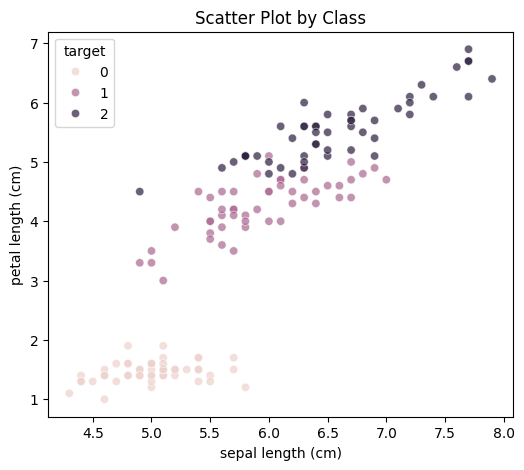

In [3]:
# 두 변수를 골라 sactter plot 확인

a1 = 'sepal length (cm)'
a2 = 'petal length (cm)'

plot_df = X[[a1, a2]].copy()
plot_df['target'] = y

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=plot_df,
    x=a1,
    y=a2,
    hue='target',
    alpha=0.7
)
plt.title("Scatter Plot by Class")
plt.show()

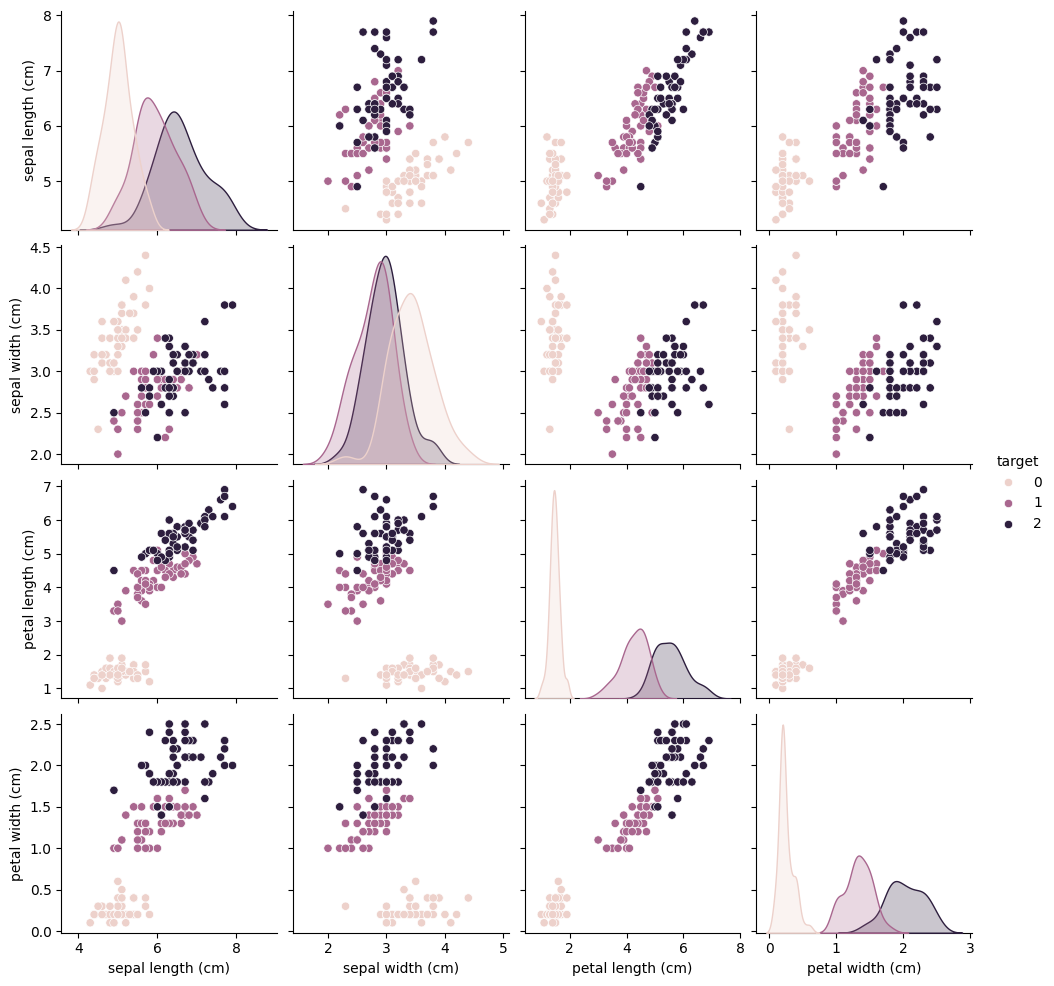

In [4]:
plot_df = X.copy()
plot_df['target'] = y

sns.pairplot(plot_df, hue='target', diag_kind='kde')

In [5]:
import plotly.express as px

fig = px.scatter_3d(
    X,
    x='sepal length (cm)',
    y='sepal width (cm)',
    z='petal length (cm)',
    color=y.astype(str),
    title="Iris 3D Scatter Plot",
)

fig.update_traces(
    marker=dict(
        size=2,
    ))

fig.update_layout(
    template="plotly_white",
    legend_title_text="Class",
    scene=dict(
        xaxis_title='Sepal Length',
        yaxis_title='Sepal Width',
        zaxis_title='Petal Length'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

**[Binary classification]**
* Use only
  * 'sepal length (cm)' and 'sepal width (cm)'
  * class 0 (setosa) and class 1 (versicolor)

Binary X shape: (100, 2)
Binary y shape: (100,)
Classes: [np.str_('setosa'), np.str_('versicolor')]


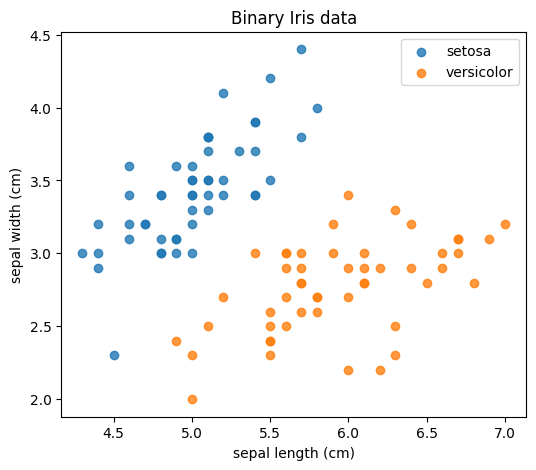

In [6]:
binary_mask = y.isin([0, 1])

X_bin = X.loc[binary_mask, [X.columns[0], X.columns[1]]].copy()
y_bin = y.loc[binary_mask].copy()

print("Binary X shape:", X_bin.shape)
print("Binary y shape:", y_bin.shape)
print("Classes:", [target_names[i] for i in sorted(y_bin.unique())])

plt.figure(figsize=(6, 5))

for class_idx in sorted(y_bin.unique()):
    mask = (y_bin == class_idx)
    plt.scatter(
        X_bin.loc[mask, X_bin.columns[0]],
        X_bin.loc[mask, X_bin.columns[1]],
        label=target_names[class_idx],
        alpha=0.8
    )

plt.xlabel(X_bin.columns[0])
plt.ylabel(X_bin.columns[1])
plt.title("Binary Iris data")
plt.legend()
plt.show()

In [7]:
# [LDA representation]

X_bin_np = X_bin.to_numpy()
y_bin_np = y_bin.to_numpy()

X0 = X_bin_np[y_bin_np == 0]
X1 = X_bin_np[y_bin_np == 1]

# 1. 클래스 평균 & 클래스 별 scatter (S0, S1)
mu0 = X0.mean(axis=0)
mu1 = X1.mean(axis=0)
print("mu0 =", mu0)
print("mu1 =", mu1)
print()

S0 = (X0 - mu0).T @ (X0 - mu0)
S1 = (X1 - mu1).T @ (X1 - mu1)
print("S0 =\n", S0)
print()
print("S1 =\n", S1)
print()

# 2. within-class scatter
SW = S0 + S1
print("SW =\n", SW)
print()

# 3. w
w_raw = np.linalg.pinv(SW) @ (mu1 - mu0)
w = w_raw / np.linalg.norm(w_raw)
print("w_raw =", w_raw)
print("normalized w =", w)

mu0 = [5.006 3.428]
mu1 = [5.936 2.77 ]

S0 =
 [[6.0882 4.8616]
 [4.8616 7.0408]]

S1 =
 [[13.0552  4.174 ]
 [ 4.174   4.825 ]]

SW =
 [[19.1434  9.0356]
 [ 9.0356 11.8658]]

w_raw = [ 0.11669751 -0.14431661]
normalized w = [ 0.62877427 -0.77758788]


In [8]:
# 입력 벡터 1차원 projection

proj_bin = X_bin_np @ w

m0 = proj_bin[y_bin_np == 0].mean()
m1 = proj_bin[y_bin_np == 1].mean()

print("Projected class mean m0 =", m0)
print("Projected class mean m1 =", m1)

Projected class mean m0 = 0.4820727382771258
Projected class mean m1 = 1.5784856375327454


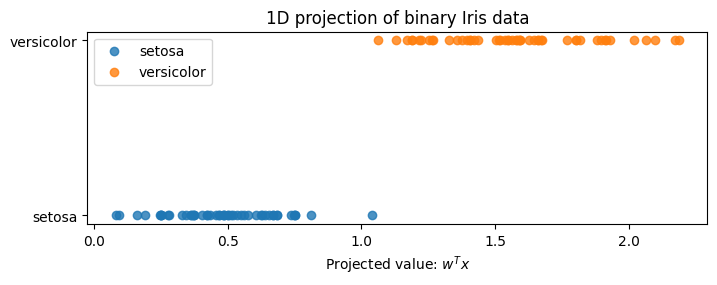

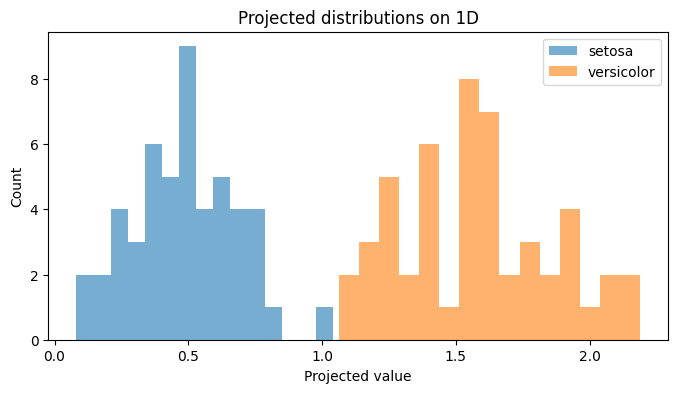

In [9]:
plt.figure(figsize=(8, 2.5))

plt.scatter(proj_bin[y_bin_np == 0], np.zeros(np.sum(y_bin_np == 0)),
            label=target_names[0], alpha=0.8)
plt.scatter(proj_bin[y_bin_np == 1], np.ones(np.sum(y_bin_np == 1)),
            label=target_names[1], alpha=0.8)

plt.yticks([0, 1], [target_names[0], target_names[1]])
plt.xlabel("Projected value: $w^T x$")
plt.title("1D projection of binary Iris data")
plt.legend()
plt.show()


plt.figure(figsize=(8, 4))

plt.hist(proj_bin[y_bin_np == 0], bins=15, alpha=0.6, label=target_names[0])
plt.hist(proj_bin[y_bin_np == 1], bins=15, alpha=0.6, label=target_names[1])

plt.xlabel("Projected value")
plt.ylabel("Count")
plt.title("Projected distributions on 1D")
plt.legend()
plt.show()

**[bias / threshold effect]**

threshold = 1.0302791879049356
bias b = -1.0302791879049356


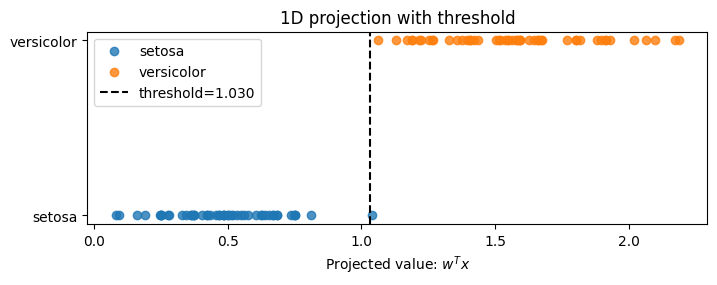

In [10]:
threshold_mid = (m0 + m1) / 2 # projected class mean의 중간값
b_mid = -threshold_mid

print("threshold =", threshold_mid)
print("bias b =", b_mid)

plt.figure(figsize=(8, 2.5))

plt.scatter(proj_bin[y_bin_np == 0], np.zeros(np.sum(y_bin_np == 0)),
            label=target_names[0], alpha=0.8)
plt.scatter(proj_bin[y_bin_np == 1], np.ones(np.sum(y_bin_np == 1)),
            label=target_names[1], alpha=0.8)

plt.axvline(threshold_mid, color='black', linestyle='--', label=f"threshold={threshold_mid:.3f}")

plt.yticks([0, 1], [target_names[0], target_names[1]])
plt.xlabel("Projected value: $w^T x$")
plt.title("1D projection with threshold")
plt.legend()
plt.show()

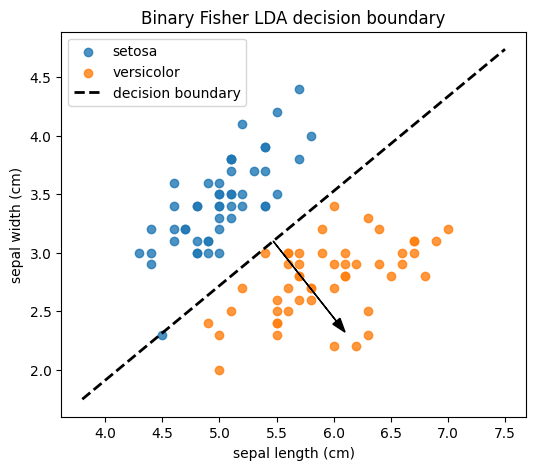

In [11]:
plt.figure(figsize=(6, 5))

for class_idx in sorted(y_bin.unique()):
    mask = (y_bin_np == class_idx)
    plt.scatter(
        X_bin_np[mask, 0],
        X_bin_np[mask, 1],
        label=target_names[class_idx],
        alpha=0.8
    )

x_min, x_max = X_bin_np[:, 0].min() - 0.5, X_bin_np[:, 0].max() + 0.5
xs = np.linspace(x_min, x_max, 200)

if abs(w[1]) > 1e-12:
    ys = -(w[0] * xs + b_mid) / w[1]
    plt.plot(xs, ys, linestyle='--', linewidth=2, color='black', label='decision boundary')
else:
    x_const = -b_mid / w[0]
    plt.axvline(x_const, linestyle='--', linewidth=2, color='black', label='decision boundary')

# projection direction
center = X_bin_np.mean(axis=0)
plt.arrow(center[0], center[1], w[0], w[1],
          head_width=0.08, length_includes_head=True, color='black')

plt.xlabel(X_bin.columns[0])
plt.ylabel(X_bin.columns[1])
plt.title("Binary Fisher LDA decision boundary")
plt.legend()
plt.show()

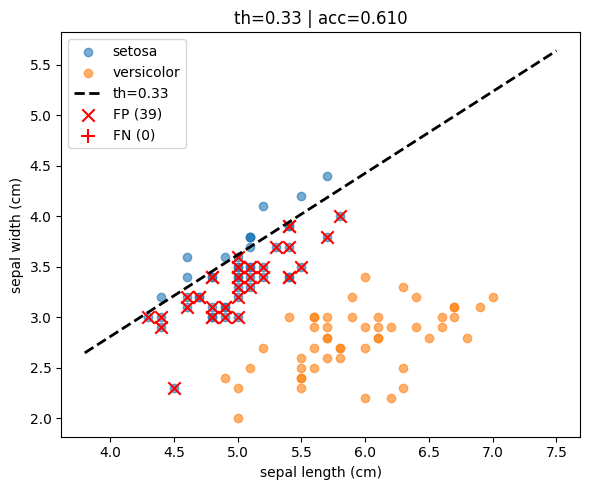

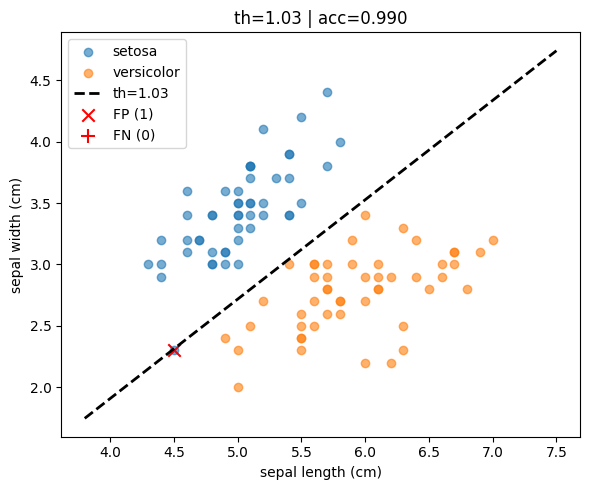

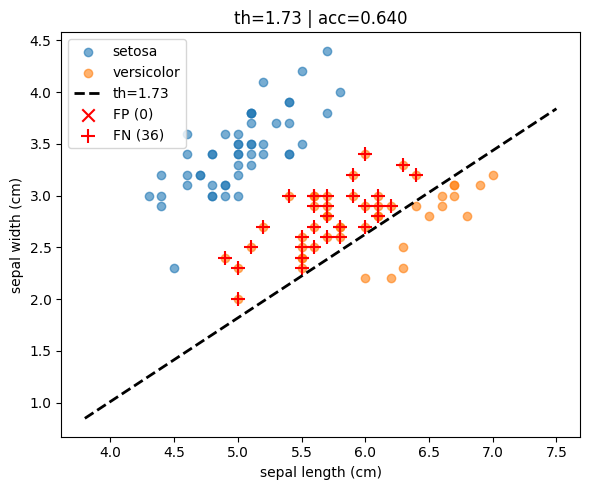

In [12]:
threshold_list = [
    threshold_mid - 0.7,
    threshold_mid,
    threshold_mid + 0.7
]

for threshold in threshold_list:
    plt.figure(figsize=(6, 5))

    y_pred = (proj_bin >= threshold).astype(int)
    acc = accuracy_score(y_bin_np, y_pred)

    for class_idx in sorted(y_bin.unique()):
        mask = (y_bin_np == class_idx)
        plt.scatter(
            X_bin_np[mask, 0],
            X_bin_np[mask, 1],
            label=target_names[class_idx],
            alpha=0.6
        )

    b = -threshold
    x_min, x_max = X_bin_np[:, 0].min() - 0.5, X_bin_np[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    if abs(w[1]) > 1e-12:
        ys = -(w[0] * xs + b) / w[1]
        plt.plot(xs, ys, linestyle='--', linewidth=2, color='black', label=f'th={threshold:.2f}')
    else:
        x_const = -b / w[0]
        plt.axvline(x_const, linestyle='--', linewidth=2, color='black', label=f'th={threshold:.2f}')

    fp_mask = (y_bin_np == 0) & (y_pred == 1)  # False Positive
    fn_mask = (y_bin_np == 1) & (y_pred == 0)  # False Negative

    plt.scatter(
        X_bin_np[fp_mask, 0],
        X_bin_np[fp_mask, 1],
        color='red',
        marker='x',
        s=80,
        label=f'FP ({fp_mask.sum()})'
    )

    plt.scatter(
        X_bin_np[fn_mask, 0],
        X_bin_np[fn_mask, 1],
        color='red',
        marker='+',
        s=90,
        label=f'FN ({fn_mask.sum()})'
    )

    plt.title(f"th={threshold:.2f} | acc={acc:.3f}")

    plt.xlabel(X_bin.columns[0])
    plt.ylabel(X_bin.columns[1])
    plt.legend(loc='best')

    plt.tight_layout()
    plt.show()

**[Compare Mean-difference only vs. Fisher criterion]**
* Mean-difference only: $w_{\text{mean}} ∝ \mu_1 - \mu_0$
* Fisher criterion: $w_{\text{fisher}} ∝ S_W^{-1}(\mu_1 - \mu_0)$

In [13]:
w_mean = mu1 - mu0
w_mean = w_mean / np.linalg.norm(w_mean)
proj_mean = X_bin_np @ w_mean
t_mean = (proj_mean[y_bin_np == 0].mean() + proj_mean[y_bin_np == 1].mean()) / 2

w_fisher = w.copy()
proj_fisher = X_bin_np @ w_fisher
t_fisher = (proj_fisher[y_bin_np == 0].mean() + proj_fisher[y_bin_np == 1].mean()) / 2

In [14]:
def format_equation(w, t, name):
    w_str = " + ".join([f"{wi:.3f}·x{i}" for i, wi in enumerate(w)])
    print(f"[{name}]")
    print(f"{w_str} = {t:.3f}")

print("=== Linear Classifiers ===\n")

format_equation(w_mean, t_mean, "Mean Difference")
print()
format_equation(w_fisher, t_fisher, "Fisher LDA")

=== Linear Classifiers ===

[Mean Difference]
0.816·x0 + -0.578·x1 = 2.676

[Fisher LDA]
0.629·x0 + -0.778·x1 = 1.030


In [15]:
diff = (mu1 - mu0).reshape(-1, 1)
SB = diff @ diff.T

def fisher_ratio(w_vec, SB, SW):
    w_vec = w_vec.reshape(-1, 1)
    numerator = (w_vec.T @ SB @ w_vec).item()
    denominator = (w_vec.T @ SW @ w_vec).item()
    return numerator / denominator

J_mean = fisher_ratio(w_mean, SB, SW)
J_fisher = fisher_ratio(w_fisher, SB, SW)

print("J(w_mean)   =", J_mean)
print("J(w_fisher) =", J_fisher)

J(w_mean)   = 0.15837109858192192
J(w_fisher) = 0.20348901794321747


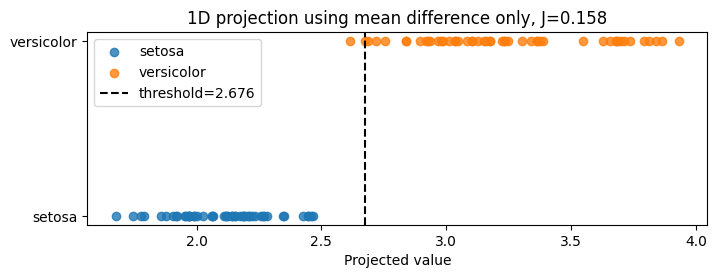

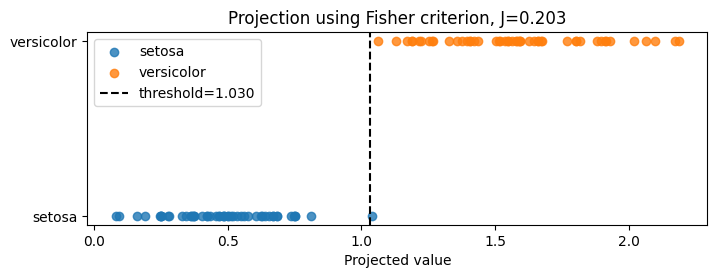

In [16]:
plt.figure(figsize=(8, 2.5))
plt.scatter(proj_mean[y_bin_np == 0], np.zeros(np.sum(y_bin_np == 0)),
            label=target_names[0], alpha=0.8)
plt.scatter(proj_mean[y_bin_np == 1], np.ones(np.sum(y_bin_np == 1)),
            label=target_names[1], alpha=0.8)
plt.axvline(t_mean, color='black', linestyle='--', label=f"threshold={t_mean:.3f}")
plt.yticks([0, 1], [target_names[0], target_names[1]])
plt.xlabel("Projected value")
plt.title(f"1D projection using mean difference only, J={J_mean:.3f}")
plt.legend()

plt.figure(figsize=(8, 2.5))
plt.scatter(proj_fisher[y_bin_np == 0], np.zeros(np.sum(y_bin_np == 0)),
            label=target_names[0], alpha=0.8)
plt.scatter(proj_fisher[y_bin_np == 1], np.ones(np.sum(y_bin_np == 1)),
            label=target_names[1], alpha=0.8)
plt.axvline(t_fisher, color='black', linestyle='--', label=f"threshold={t_fisher:.3f}")
plt.yticks([0, 1], [target_names[0], target_names[1]])
plt.xlabel("Projected value")
plt.title(f"Projection using Fisher criterion, J={J_fisher:.3f}")
plt.legend()

plt.show()

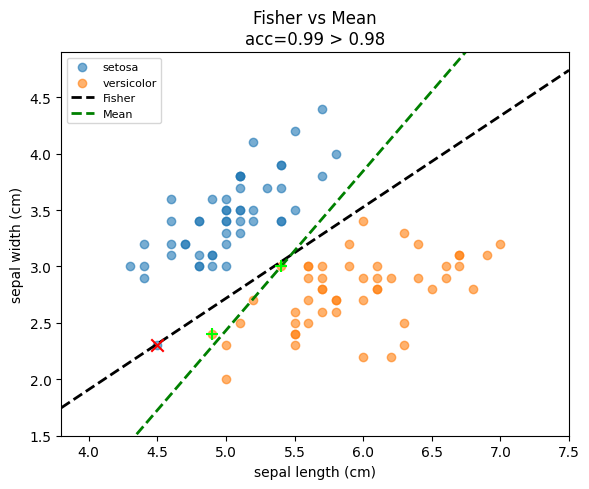

In [17]:
plt.figure(figsize=(6, 5))

# scatter
for class_idx in sorted(y_bin.unique()):
    mask = (y_bin_np == class_idx)
    plt.scatter(
        X_bin_np[mask, 0],
        X_bin_np[mask, 1],
        label=target_names[class_idx],
        alpha=0.6,
        zorder=1
    )

x_min, x_max = X_bin_np[:, 0].min() - 0.5, X_bin_np[:, 0].max() + 0.5
y_min, y_max = X_bin_np[:, 1].min() - 0.5, X_bin_np[:, 1].max() + 0.5
xs = np.linspace(x_min, x_max, 200)

center = X_bin_np.mean(axis=0)

# =======================
# Fisher
# =======================
if abs(w_fisher[1]) > 1e-12:
    ys_fisher = (t_fisher - w_fisher[0] * xs) / w_fisher[1]
    plt.plot(xs, ys_fisher, '--', color='black', linewidth=2, label='Fisher', zorder=2)
else:
    x_const = t_fisher / w_fisher[0]
    plt.axvline(x_const, linestyle='--', color='black', linewidth=2, label='Fisher', zorder=2)

proj = X_bin_np @ w_fisher
y_pred = (proj >= t_fisher).astype(int)

fp = (y_bin_np == 0) & (y_pred == 1)
fn = (y_bin_np == 1) & (y_pred == 0)
acc = accuracy_score(y_bin_np, y_pred)

plt.scatter(X_bin_np[fp, 0], X_bin_np[fp, 1], color='red', marker='x', s=80, zorder=4)
plt.scatter(X_bin_np[fn, 0], X_bin_np[fn, 1], color='red', marker='+', s=80, zorder=4)

# =======================
# Mean
# =======================
if abs(w_mean[1]) > 1e-12:
    ys_mean = (t_mean - w_mean[0] * xs) / w_mean[1]
    plt.plot(xs, ys_mean, '--', color='green', linewidth=2, label='Mean', zorder=2)
else:
    x_const = t_mean / w_mean[0]
    plt.axvline(x_const, linestyle='--', color='green', linewidth=2, label='Mean', zorder=2)

proj_mean = X_bin_np @ w_mean
y_pred_mean = (proj_mean >= t_mean).astype(int)

fp_m = (y_bin_np == 0) & (y_pred_mean == 1)
fn_m = (y_bin_np == 1) & (y_pred_mean == 0)
acc_m = accuracy_score(y_bin_np, y_pred_mean)

plt.scatter(X_bin_np[fp_m, 0], X_bin_np[fp_m, 1],
            color='lime', marker='x', s=80, zorder=4)

plt.scatter(X_bin_np[fn_m, 0], X_bin_np[fn_m, 1],
            color='lime', marker='+', s=80, zorder=4)

# =======================
plt.xlabel(X_bin.columns[0])
plt.ylabel(X_bin.columns[1])
plt.title(f"Fisher vs Mean\nacc={acc} > {acc_m}")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
def separation_stats(proj, y_true):
    m0 = proj[y_true == 0].mean()
    m1 = proj[y_true == 1].mean()

    s0 = np.var(proj[y_true == 0], ddof=1)
    s1 = np.var(proj[y_true == 1], ddof=1)

    between = (m1 - m0) ** 2
    within = s0 + s1
    ratio = between / within

    return between, within, ratio

between_mean, within_mean, ratio_mean = separation_stats(proj_mean, y_bin_np)
between_fisher, within_fisher, ratio_fisher = separation_stats(proj_fisher, y_bin_np)

improvement = ratio_fisher / ratio_mean

print("[Mean difference only]")
print("between =", between_mean)
print("within  =", within_mean)
print("ratio   =", ratio_mean)
print()

print("[Fisher LDA]")
print("between =", between_fisher)
print("within  =", within_fisher)
print("ratio   =", ratio_fisher)
print()

print("="*40)
print(f"Better projection: Fisher (x{improvement:.2f} improvement)")

[Mean difference only]
between = 1.2978640000000001
within  = 0.16724655347681477
ratio   = 7.760183830514162

[Fisher LDA]
between = 1.2021212456541137
within  = 0.1205622145802884
ratio   = 9.970961879217647

Better projection: Fisher (x1.28 improvement)


**[Classification for new data x']**

$$
t = \text{argmin}_k d(W^{T}{\bf{x}'}, W^{T}\mu_k)
$$

In [19]:
x_new = np.array([
    np.random.uniform(x_min, x_max),
    np.random.uniform(y_min, y_max)
])

proj_new = x_new @ w
dist_to_m0 = abs(proj_new - m0)
dist_to_m1 = abs(proj_new - m1)

pred_by_nearest_mean = 0 if dist_to_m0 < dist_to_m1 else 1
pred_by_threshold = 1 if proj_new >= threshold_mid else 0

print("x' =", x_new)
print("Projected x' =", proj_new)
print("Distance to projected class mean 0 =", dist_to_m0)
print("Distance to projected class mean 1 =", dist_to_m1)
print("Prediction by nearest projected mean =", pred_by_nearest_mean)
print("Prediction by threshold             =", pred_by_threshold)

x' = [4.66113359 4.52442873]
Projected x' = -0.5873400835093139
Distance to projected class mean 0 = 1.0694128217864396
Distance to projected class mean 1 = 2.1658257210420593
Prediction by nearest projected mean = 0
Prediction by threshold             = 0


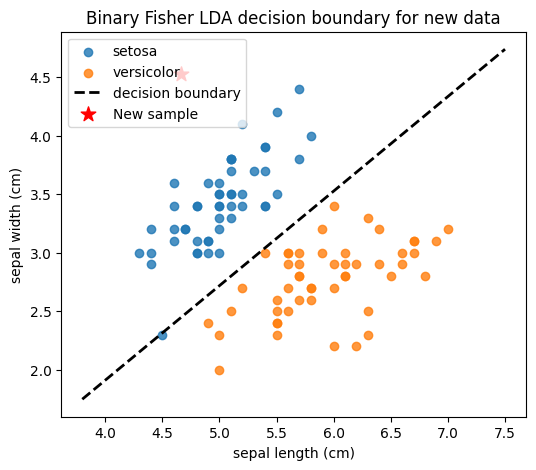

In [20]:
plt.figure(figsize=(6, 5))

for class_idx in sorted(y_bin.unique()):
    mask = (y_bin_np == class_idx)
    plt.scatter(
        X_bin_np[mask, 0],
        X_bin_np[mask, 1],
        label=target_names[class_idx],
        alpha=0.8
    )

x_min, x_max = X_bin_np[:, 0].min() - 0.5, X_bin_np[:, 0].max() + 0.5
xs = np.linspace(x_min, x_max, 200)

if abs(w[1]) > 1e-12:
    ys = -(w[0] * xs + b_mid) / w[1]
    plt.plot(xs, ys, linestyle='--', linewidth=2, color='black', label='decision boundary')
else:
    x_const = -b_mid / w[0]
    plt.axvline(x_const, linestyle='--', linewidth=2, color='black', label='decision boundary')

plt.scatter(x_new[0], x_new[1],
            color='red', s=120, marker='*',
            label='New sample', zorder=5)

plt.xlabel(X_bin.columns[0])
plt.ylabel(X_bin.columns[1])
plt.title("Binary Fisher LDA decision boundary for new data")
plt.legend()
plt.show()

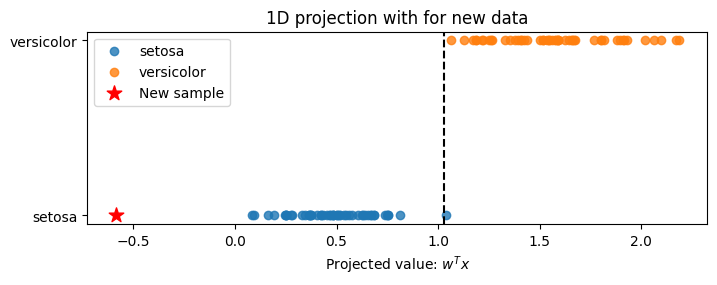

In [21]:
plt.figure(figsize=(8, 2.5))

plt.scatter(proj_bin[y_bin_np == 0], np.zeros(np.sum(y_bin_np == 0)),
            label=target_names[0], alpha=0.8)
plt.scatter(proj_bin[y_bin_np == 1], np.ones(np.sum(y_bin_np == 1)),
            label=target_names[1], alpha=0.8)

plt.axvline(t_fisher, color='black', linestyle='--')

y_pos = pred_by_threshold
plt.scatter(proj_new, y_pos,
            color='red', marker='*', s=120,
            label='New sample', zorder=5)

plt.yticks([0, 1], [target_names[0], target_names[1]])
plt.xlabel("Projected value: $w^T x$")
plt.title("1D projection with for new data")
plt.legend()
plt.show()

### **Exercise 1**
Iris dataset의 모든 feature를 활용하여 LDA 방향 $\bf{w}$ 구하기

In [22]:
X_bin_full = X.loc[binary_mask].copy()
y_bin_full = y.loc[binary_mask].copy()

X_bin_full_np = X_bin_full.to_numpy()
y_bin_full_np = y_bin_full.to_numpy()

In [23]:
# w 구하기

X0_full = X_bin_full_np[y_bin_full_np == 0]
X1_full = X_bin_full_np[y_bin_full_np == 1]

mu0_full = X0_full.mean(axis=0)
mu1_full = X1_full.mean(axis=0)

S0_full = (X0_full - mu0_full).T @ (X0_full - mu0_full)
S1_full = (X1_full - mu1_full).T @ (X1_full - mu1_full)
SW_full = S0_full + S1_full

w_full_raw = np.linalg.pinv(SW_full) @ (mu1_full - mu0_full)
w_full = w_full_raw / np.linalg.norm(w_full_raw)

print("mu0 =", mu0_full)
print("mu1 =", mu1_full)
print()
print("SW =\n", SW_full)
print()
print("w_raw =", w_full_raw)
print("normalized w =", w_full)

mu0 = [5.006 3.428 1.462 0.246]
mu1 = [5.936 2.77  4.26  1.326]

SW =
 [[19.1434  9.0356  9.7634  3.2394]
 [ 9.0356 11.8658  4.6232  2.4746]
 [ 9.7634  4.6232 12.2978  3.8794]
 [ 3.2394  2.4746  3.8794  2.4604]]

w_raw = [-0.03115072 -0.18390775  0.22210403  0.31473638]
normalized w = [-0.07278252 -0.4296938   0.51893802  0.73537016]


In [24]:
# 1차원 projection

proj_full = X_bin_full_np @ w_full

m0_full = proj_full[y_bin_full_np == 0].mean()
m1_full = proj_full[y_bin_full_np == 1].mean()

threshold_full = (m0_full + m1_full) / 2

print("Projected mean of class 0:", m0_full)
print("Projected mean of class 1:", m1_full)
print("Threshold:", threshold_full)

Projected mean of class 0: -0.8977512052966773
Projected mean of class 1: 1.5634879326000999
Threshold: 0.3328683636517113


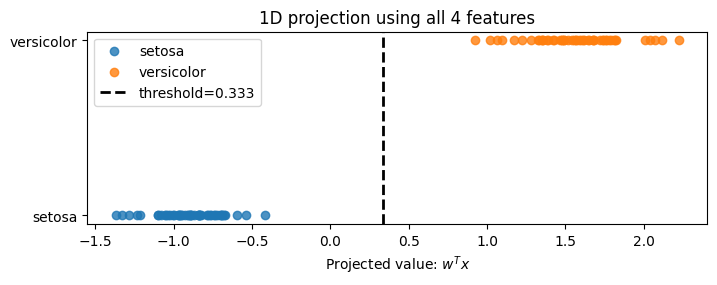

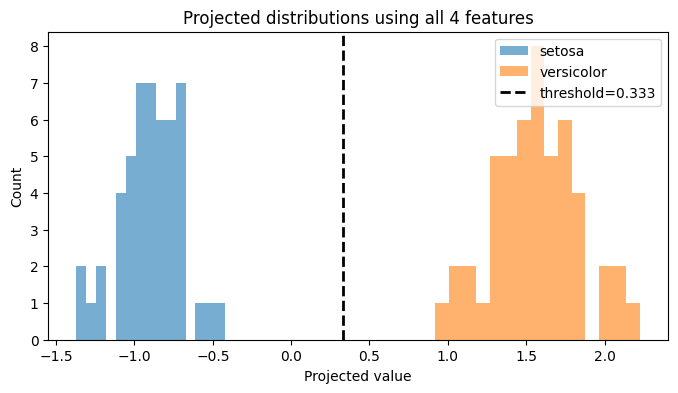

In [25]:
plt.figure(figsize=(8, 2.5))

plt.scatter(
    proj_full[y_bin_full_np == 0],
    np.zeros(np.sum(y_bin_full_np == 0)),
    label=target_names[0],
    alpha=0.8
)
plt.scatter(
    proj_full[y_bin_full_np == 1],
    np.ones(np.sum(y_bin_full_np == 1)),
    label=target_names[1],
    alpha=0.8
)

plt.axvline(threshold_full, linestyle='--', color='black', linewidth=2, label=f"threshold={threshold_full:.3f}")

plt.yticks([0, 1], [target_names[0], target_names[1]])
plt.xlabel("Projected value: $w^T x$")
plt.title("1D projection using all 4 features")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))

plt.hist(proj_full[y_bin_full_np == 0], bins=15, alpha=0.6, label=target_names[0])
plt.hist(proj_full[y_bin_full_np == 1], bins=15, alpha=0.6, label=target_names[1])

plt.axvline(threshold_full, linestyle='--', color='black', linewidth=2, label=f"threshold={threshold_full:.3f}")

plt.xlabel("Projected value")
plt.ylabel("Count")
plt.title("Projected distributions using all 4 features")
plt.legend()
plt.show()

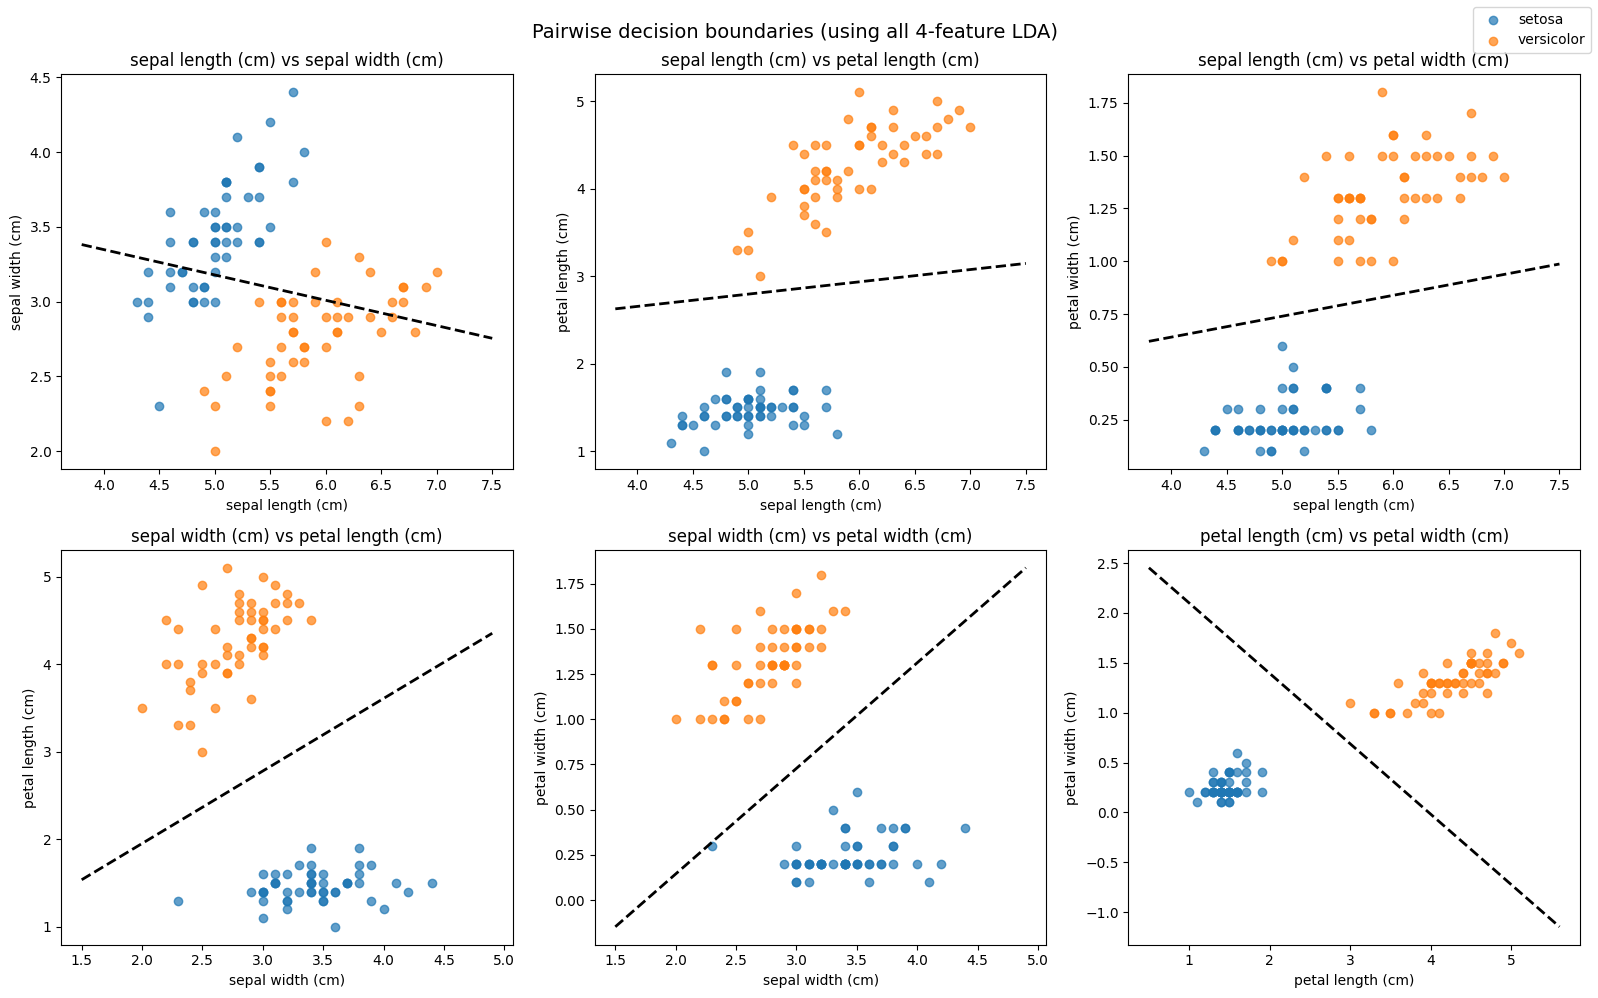

In [26]:
from itertools import combinations

feature_pairs = list(combinations(range(X_bin_full.shape[1]), 2))
feature_names = list(X_bin_full.columns)

fixed_means = X_bin_full_np.mean(axis=0)
b_full = -threshold_full

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (i, j) in zip(axes, feature_pairs):
    # scatter
    for class_idx in sorted(np.unique(y_bin_full_np)):
        mask = (y_bin_full_np == class_idx)
        ax.scatter(
            X_bin_full_np[mask, i],
            X_bin_full_np[mask, j],
            label=target_names[class_idx],
            alpha=0.7
        )

    x_min, x_max = X_bin_full_np[:, i].min() - 0.5, X_bin_full_np[:, i].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # w^T x + b = 0
    # only xi, xj vary; others fixed at dataset mean
    other_sum = 0.0
    for k in range(X_bin_full.shape[1]):
        if k not in [i, j]:
            other_sum += w_full[k] * fixed_means[k]

    if abs(w_full[j]) > 1e-12:
        ys = -(w_full[i] * xs + other_sum + b_full) / w_full[j]
        ax.plot(xs, ys, linestyle='--', color='black', linewidth=2)
    else:
        x_const = -(other_sum + b_full) / w_full[i]
        ax.axvline(x_const, linestyle='--', color='black', linewidth=2)

    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.set_title(f"{feature_names[i]} vs {feature_names[j]}")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Pairwise decision boundaries (using all 4-feature LDA)", fontsize=14)
plt.tight_layout()
plt.show()

**[Multi-class Fisher LDA]**
* $S_W$: Within-class scatter
  * **i = j**: 각 feature의 클래스 내부 분산, 작을수록 유리
  * **i ≠ j**: 두 feature 간 클래스 내부 공분산, 값이 클 경우 두 feature가 같이 증가하거나 반대로 움직임
* $S_B$: Between-class scatter
  * **i = j**: 각 feature의 클래스 간 평균 차이, 클수록 분류에 중요한 feature임
  * **i ≠ j**: 두 feature 조합의 클래스 간 분리 방향, 값이 클 경우 두 feature를 같이 보면 잘 나뉨

In [27]:
X_multi = X.to_numpy()
y_multi = y.to_numpy()

classes = np.unique(y_multi)
n_features = X_multi.shape[1]

mu_global = X_multi.mean(axis=0)

SW_multi = np.zeros((n_features, n_features))
SB_multi = np.zeros((n_features, n_features))

class_means = {}

for c in classes:
    Xc = X_multi[y_multi == c]
    mu_c = Xc.mean(axis=0)
    n_c = Xc.shape[0]

    class_means[c] = mu_c

    SW_multi += (Xc - mu_c).T @ (Xc - mu_c)

    diff = (mu_c - mu_global).reshape(-1, 1)
    SB_multi += n_c * (diff @ diff.T)

print("Global mean =", mu_global)
print()
print("Class means:")
for c in classes:
    print(f"{target_names[c]}:", class_means[c])

print()
print("SW =\n", SW_multi)
print()
print("SB =\n", SB_multi)

Global mean = [5.84333333 3.05733333 3.758      1.19933333]

Class means:
setosa: [5.006 3.428 1.462 0.246]
versicolor: [5.936 2.77  4.26  1.326]
virginica: [6.588 2.974 5.552 2.026]

SW =
 [[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]

SB =
 [[ 63.21213333 -19.95266667 165.2484      71.27933333]
 [-19.95266667  11.34493333 -57.2396     -22.93266667]
 [165.2484     -57.2396     437.1028     186.774     ]
 [ 71.27933333 -22.93266667 186.774       80.41333333]]


In [28]:
M = np.linalg.pinv(SW_multi) @ SB_multi

eigvals, eigvecs = np.linalg.eig(M)

idx = np.argsort(np.real(eigvals))[::-1]
eigvals = np.real(eigvals[idx])
eigvecs = np.real(eigvecs[:, idx])

w_multi_1d = np.real(eigvecs[:, 0])
w_multi_1d = w_multi_1d / np.linalg.norm(w_multi_1d)

print("Eigenvalues =", eigvals)
print()
print("Representative 1D direction w =")
print(w_multi_1d)

Eigenvalues = [ 3.21919292e+01  2.85391043e-01  6.53235352e-15 -6.28087298e-15]

Representative 1D direction w =
[ 0.20874182  0.38620369 -0.55401172 -0.7073504 ]


Projected class means:
setosa: 1.3849
versicolor: -0.9892
virginica: -1.9852

Sorted projected means:
virginica -> -1.9852040636396533
versicolor -> -0.9891608693414241
setosa -> 1.3848944708370345

Decision boundaries (thresholds):
between virginica and versicolor: -1.4872
between versicolor and setosa: 0.1979


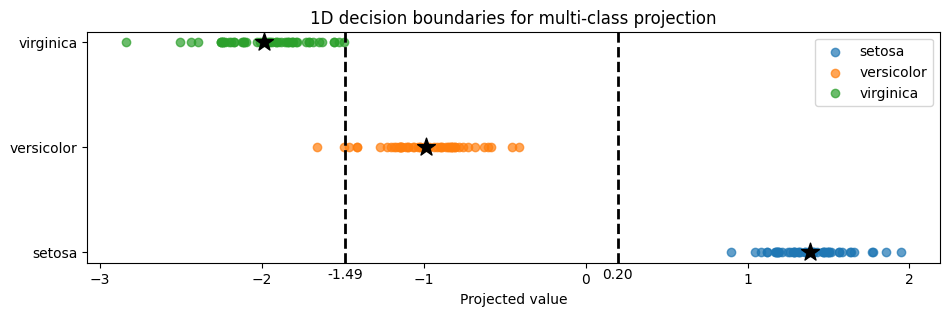

Accuracy = 0.9866666666666667
Number of misclassified samples = 2


In [29]:
proj_multi_1d = X_multi @ w_multi_1d

projected_class_means = {}

for c in classes:
    projected_class_means[c] = proj_multi_1d[y_multi == c].mean()

print("Projected class means:")
for c in classes:
    print(f"{target_names[c]}: {projected_class_means[c]:.4f}")
print()
# projected mean 정렬
sorted_means = sorted(projected_class_means.items(), key=lambda x: x[1])

print("Sorted projected means:")
for c, m in sorted_means:
    print(target_names[c], "->", m)

sorted_classes = [c for c, _ in sorted_means]
sorted_mean_values = np.array([m for _, m in sorted_means])

def predict_class_from_projection(proj_val, sorted_classes, sorted_mean_values):
    dists = np.abs(sorted_mean_values - proj_val)
    return sorted_classes[np.argmin(dists)]

y_pred_multi_1d = np.array([
    predict_class_from_projection(v, sorted_classes, sorted_mean_values)
    for v in proj_multi_1d
])
mis_mask = (y_pred_multi_1d != y_multi)

thresholds = []
for i in range(len(sorted_means) - 1):
    c1, m1 = sorted_means[i]
    c2, m2 = sorted_means[i + 1]
    t = (m1 + m2) / 2
    thresholds.append((c1, c2, t))

print()
print("Decision boundaries (thresholds):")

for c1, c2, t in thresholds:
    print(f"between {target_names[c1]} and {target_names[c2]}: {t:.4f}")

plt.figure(figsize=(11, 3))

for c in classes:
    mask = (y_multi == c)
    plt.scatter(
        proj_multi_1d[mask],
        np.full(np.sum(mask), c),
        label=target_names[c],
        alpha=0.7
    )

for c in classes:
    mean_val = projected_class_means[c]
    plt.scatter(mean_val, c, color='black', marker='*', s=180)

for c1, c2, t in thresholds:
    plt.axvline(t, linestyle='--', color='black', linewidth=2)
    plt.text(t, -0.25, f"{t:.2f}", ha='center')

plt.yticks(classes, [target_names[c] for c in classes])
plt.xlabel("Projected value")
plt.title("1D decision boundaries for multi-class projection")
plt.legend()
plt.show()

print("Accuracy =", (y_pred_multi_1d == y_multi).mean())
print("Number of misclassified samples =", np.sum(mis_mask))

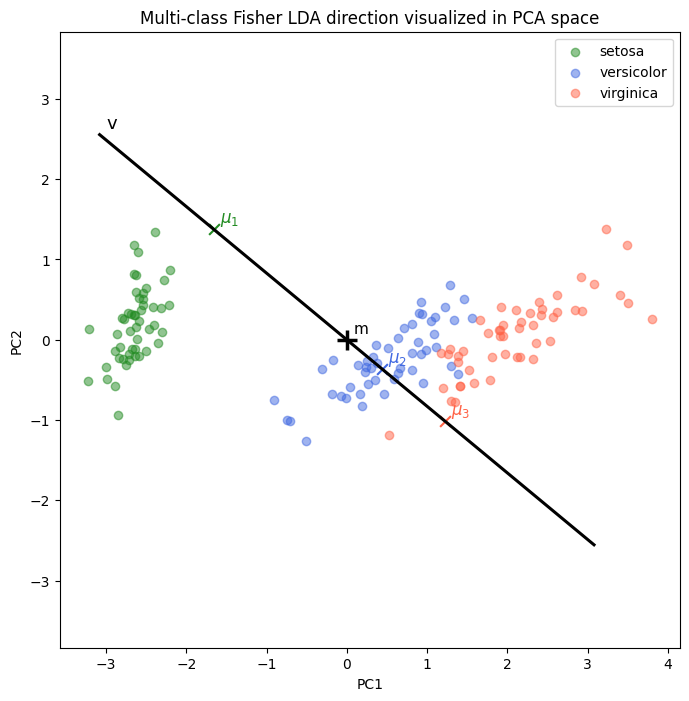

In [30]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)
X_multi_pca = pca_vis.fit_transform(X_multi)

global_mean = X_multi.mean(axis=0)
w_prev = w_multi_1d.copy()

global_mean_pca = pca_vis.transform(global_mean.reshape(1, -1))[0]

point_along_w = global_mean + w_prev
point_along_w_pca = pca_vis.transform(point_along_w.reshape(1, -1))[0]

v_pca = point_along_w_pca - global_mean_pca
v_pca = v_pca / np.linalg.norm(v_pca)

def project_point_to_line_2d(point, line_point, direction):
    direction = direction / np.linalg.norm(direction)
    return line_point + np.dot(point - line_point, direction) * direction

classes = np.unique(y_multi)

class_means_pca = {}
for c in classes:
    class_means_pca[c] = X_multi_pca[y_multi == c].mean(axis=0)

projected_class_means_pca = {}
for c in classes:
    projected_class_means_pca[c] = project_point_to_line_2d(
        class_means_pca[c],
        global_mean_pca,
        v_pca
    )

plt.figure(figsize=(8, 8))

colors = ['forestgreen', 'royalblue', 'tomato']

for c, color in zip(classes, colors):
    mask = (y_multi == c)
    plt.scatter(
        X_multi_pca[mask, 0],
        X_multi_pca[mask, 1],
        color=color,
        alpha=0.5,
        label=target_names[c]
    )

plt.scatter(
    global_mean_pca[0], global_mean_pca[1],
    color='black', marker='+', s=220, linewidths=2.5
)
plt.text(
    global_mean_pca[0] + 0.08, global_mean_pca[1] + 0.08,
    "m", fontsize=11
)

line_scale = 4.0
p1 = global_mean_pca - line_scale * v_pca
p2 = global_mean_pca + line_scale * v_pca
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='black', linewidth=2.2)
plt.text(p2[0] + 0.08, p2[1] + 0.08, "v", fontsize=13)

for idx, (c, color) in enumerate(zip(classes, colors), start=1):
    mk = class_means_pca[c]
    muk = projected_class_means_pca[c]

    plt.scatter(muk[0], muk[1], color=color, marker='x', s=60)
    plt.text(muk[0] + 0.08, muk[1] + 0.08, f"$\\mu_{idx}$", color=color, fontsize=12)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Multi-class Fisher LDA direction visualized in PCA space")
plt.axis('equal')
plt.legend()
plt.show()

x_new = [ 6.8 -2.7 -2.1  1.5]
Projected scalar value = 0.4790934397992619
distance to setosa projected mean: 0.9058
distance to versicolor projected mean: 1.4683
distance to virginica projected mean: 2.4643
predicted class = setosa


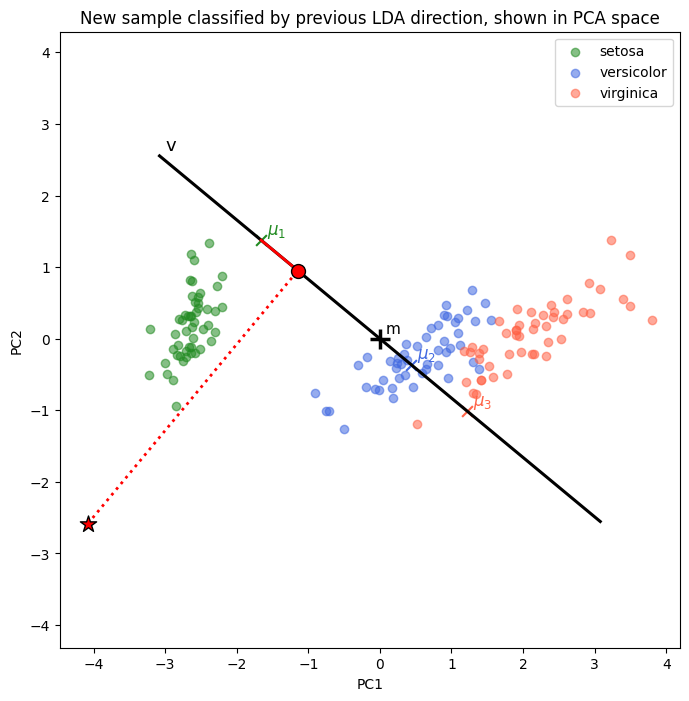

In [31]:
x_new = np.array([6.8, -2.7, -2.1, 1.5])

proj_new_scalar = x_new @ w_prev

projected_class_means_scalar = {}
for c in classes:
    Xc = X_multi[y_multi == c]
    projected_class_means_scalar[c] = np.mean(Xc @ w_prev)

dist_dict = {
    c: abs(proj_new_scalar - projected_class_means_scalar[c])
    for c in classes
}
pred_new = min(dist_dict, key=dist_dict.get)

print("x_new =", x_new)
print("Projected scalar value =", proj_new_scalar)
for c in classes:
    print(f"distance to {target_names[c]} projected mean: {dist_dict[c]:.4f}")
print("predicted class =", target_names[pred_new])

x_new_pca = pca_vis.transform(x_new.reshape(1, -1))[0]

x_new_proj_pca = project_point_to_line_2d(
    x_new_pca,
    global_mean_pca,
    v_pca
)

plt.figure(figsize=(8, 8))

colors = ['forestgreen', 'royalblue', 'tomato']

for c, color in zip(classes, colors):
    mask = (y_multi == c)
    plt.scatter(
        X_multi_pca[mask, 0],
        X_multi_pca[mask, 1],
        color=color,
        alpha=0.55,
        label=target_names[c]
    )

plt.scatter(
    global_mean_pca[0], global_mean_pca[1],
    color='black', marker='+', s=220, linewidths=2.5
)
plt.text(
    global_mean_pca[0] + 0.08, global_mean_pca[1] + 0.08,
    "m", fontsize=11
)

line_scale = 4.0
p1 = global_mean_pca - line_scale * v_pca
p2 = global_mean_pca + line_scale * v_pca
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='black', linewidth=2.2)
plt.text(p2[0] + 0.08, p2[1] + 0.08, "v", fontsize=13)

for idx, (c, color) in enumerate(zip(classes, colors), start=1):
    mk = class_means_pca[c]
    muk = projected_class_means_pca[c]

    plt.scatter(muk[0], muk[1], color=color, marker='x', s=60)
    plt.text(muk[0] + 0.08, muk[1] + 0.08, f"$\\mu_{idx}$", color=color, fontsize=12)

plt.scatter(
    x_new_pca[0], x_new_pca[1],
    color='red', edgecolors='black', marker='*', s=150, zorder=6
)

plt.scatter(
    x_new_proj_pca[0], x_new_proj_pca[1],
    color='red', edgecolors='black', marker='o', s=100, zorder=6
)

plt.plot(
    [x_new_pca[0], x_new_proj_pca[0]],
    [x_new_pca[1], x_new_proj_pca[1]],
    linestyle=':', color='red', linewidth=2
)

best_mu_pca = projected_class_means_pca[pred_new]
plt.plot(
    [x_new_proj_pca[0], best_mu_pca[0]],
    [x_new_proj_pca[1], best_mu_pca[1]],
    linestyle='-', color='red', linewidth=2
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("New sample classified by previous LDA direction, shown in PCA space")
plt.axis('equal')
plt.legend()
plt.show()

-------

### ■ **Gaussian Discriminant Analysis**
> * **discriminative 관점**
    * $p(y|x)$를 직접 모델링하거나, decision boundary를 바로 학습
      * "이 $x$가 어느 클래스인가?"

> * **generative 관점**
    * $p(x|y)$, $p(y)$를 먼저 모델링
      * "클래스 $y=k$라면 데이터 $x$는 어떤 식으로 생성되는가?"
    * Bayes rule로 $p(y|x)$를 계산하여 분류
      * "각 클래스는 원래 얼마나 자주 나타나는가?"

* **Gaussian Discriminant Analysis**
  1. 클래스 $k$에 속한 데이터의 feature 분포가 가우시안이라고 가정
  $$
  \boxed{
  p(\mathbf{x}\mid y=k,\theta)=\mathcal{N}(\mathbf{x}\mid \mu_k,\Sigma_k)
  }
  $$
    * $\mu_k$: 클래스 $k$의 평균 벡터
    * $\Sigma_k$: 클래스 $k$의 covariance matrix
    * prior는 보통 학습 데이터에서의 클래스 비율 $$\boxed{ p(y=k\mid \theta)=\frac{n_k}{n} }$$

  2. 입력 $\mathbf{x}$이 클래스 $k$에 속할 posterior probability를 Bayes rule로 계산
  $$
  \boxed{
  p(y=k\mid \mathbf{x},\theta)
  = \frac{p(y=k\mid \theta)p(\mathbf{x}\mid y=k,\theta)}
  {\sum_{k'} p(y=k'\mid \theta)p(\mathbf{x}\mid y=k',\theta)}
  }
  $$
  * prior: 원래 클래스 $k$가 얼마나 자주 나타나는가
  * likelihood: 클래스 $k$라고 했을 때, 현재 입력 $\bf{x}$가 얼마나 그럴듯한가

  3. posterior가 가장 큰 클래스를 선택하여 최종 분류
  $$
  \boxed{
  t(\mathbf{x})=\arg\max_k p(y=k\mid \mathbf{x},\theta)
  }
  $$

* **Shared covariance assumption**
  * 모든 클래스가 공통 covariance를 가질 경우
    * GDA의 score function는 선형이 됨
      * $\Sigma_k=\Sigma$ 일 때,
      * 클래스별 score function은 $\mathbf{w}^{(k)T}\mathbf{x}+w_0^{(k)}$
    * GDA의 decision boundary는 선형이 됨
      * 두 클래스 $k$와 $k'$ 사이의 decision boundary는 두 score가 같은 점들의 집합

      $$
      {\mathbf{w}^{(k)T}\mathbf{x}+w_0^{(k)}=\mathbf{w}^{(k')T}\mathbf{x}+w_0^{(k')}}
      $$
      $$
      \boxed{
      (\mathbf{w}^{(k)}-\mathbf{w}^{(k')})^T\mathbf{x}+(w_0^{(k)}-w_0^{(k')})=0
      }
      $$
      * $\mathbf{w}^{(k)}$: 클래스 평균 $\mu_k$를 covariance 구조로 보정한 weight vector
      * $w_0^{(k)}$: 평균 위치와 prior를 반영하는 bias term

* **Connection to Fisher LDA**
  * Fisher LDA와 GDA는 shared covariance 가정 아래에서는 모두 선형 decision boundary를 만듦
    * **Fisher LDA**: 클래스가 잘 분리되도록 projection 방향 $\bf{w}$을 직접 찾음 (discriminative 관점)
    * **GDA**: 클래스별 데이터 분포를 모델링하고 posterior로 분류함 (generative 관점)
        
        ⇒ 각 클래스가 데이터를 생성했을 가능성을 비교하여, 가장 그럴듯한 클래스를 선택한다.

---

In [32]:
# binary: class 0 vs class 1
binary_mask = y.isin([0, 1])

X_gda = X.loc[binary_mask].to_numpy()
y_gda = y.loc[binary_mask].to_numpy()

X0 = X_gda[y_gda == 0]
X1 = X_gda[y_gda == 1]

n0 = len(X0)
n1 = len(X1)
n = len(X_gda)

# class means
mu0 = X0.mean(axis=0)
mu1 = X1.mean(axis=0)

# priors
pi0 = n0 / n
pi1 = n1 / n

# shared covariance
S0 = (X0 - mu0).T @ (X0 - mu0)
S1 = (X1 - mu1).T @ (X1 - mu1)

Sigma = (S0 + S1) / n
Sigma_inv = np.linalg.pinv(Sigma)

print("mu0 =", mu0)
print("mu1 =", mu1)
print()
print("pi0 =", pi0)
print("pi1 =", pi1)
print()
print("Sigma =\n", Sigma)

mu0 = [5.006 3.428 1.462 0.246]
mu1 = [5.936 2.77  4.26  1.326]

pi0 = 0.5
pi1 = 0.5

Sigma =
 [[0.191434 0.090356 0.097634 0.032394]
 [0.090356 0.118658 0.046232 0.024746]
 [0.097634 0.046232 0.122978 0.038794]
 [0.032394 0.024746 0.038794 0.024604]]


In [33]:
# class-wise linear scores
w0_vec = Sigma_inv @ mu0
w1_vec = Sigma_inv @ mu1

b0 = -0.5 * mu0.T @ Sigma_inv @ mu0 + np.log(pi0)
b1 = -0.5 * mu1.T @ Sigma_inv @ mu1 + np.log(pi1)

def gda_score(X_input, w_vec, b):
    return X_input @ w_vec + b

score0 = gda_score(X_gda, w0_vec, b0)
score1 = gda_score(X_gda, w1_vec, b1)

# posterior for class 1 using softmax over two linear scores
exp0 = np.exp(score0)
exp1 = np.exp(score1)
post1 = exp1 / (exp0 + exp1)

y_pred_gda = (score1 > score0).astype(int)

print("GDA accuracy =", accuracy_score(y_gda, y_pred_gda))

GDA accuracy = 1.0


-------

# **Part 2. Evaluation**

Evaluation은 학습에 쓰지 않은 새로운 데이터에서 얼마나 잘 예측하는지 generalization performance를 추정하는 과정임



### ■ **Predictive Performance**
* **Data Partition**
  * **Training data**: 모델 학습
  * **Validation data**: 모델 선택, hyperparameter 튜닝, early stopping
  * **Test data**: 최종 성능 평가

* **Expected Prediction Error (EPE)**
  * 일반화 성능은 데이터 분포 전체에서의 평균 손실임
  $$
  \mathrm{EPE}(f) = \mathbb{E}\big[\ell(Y, f(X))\big]= \int \ell\big(Y, f(X)\big)\, dP(X,Y)
  = \mathbb{E}_X \Big[ \mathbb{E}_{Y\mid X}\big[\ell(Y, f(X)) \mid X\big] \Big]
  $$
    * Minimize EPE pointwise:
    $$
    f(x)
    = \arg\min_{c}\; \mathbb{E}_{Y\mid X}\big[\ell(Y,c)\mid X=x\big]
    $$
    * For the squared loss function,
    $$
    \boxed{
    f(x) = \mathbb{E}[Y \mid X=x]
    }
    $$

* **Empirical Risk Minimization (ERM)**
  * 실제론 진짜 데이터 분포를 모르기 때문에, 전체 risk를 직접 계산할 수 없음
  * Training data에서 loss 평균을 구한 empirical risk로 근사
  $$
  \mathcal{R}_{\mathrm{emp}}(f) = \frac{1}{N}\sum_{i=1}^{N} \ell\big(y_i, f(x_i)\big)
  $$
  * ERM으로 학습된 모델:
  $$
  f_D
  = \arg\min_{f}\; \frac{1}{N}\sum_{i=1}^{N} \ell\big(y_i, f(x_i)\big)
  $$
    * 여기서, 학습은 결국 training data에서 평균 손실이 최소가 되도록 모델 $f_D$를 찾는 과정임

* **Bias-Variance Trade-off**
  * 일반화 오차는 세 가지로 분해됨
    1. **Bias**: 모델이 너무 단순해서 생기는 오차
    2. **Variance**: 데이터 샘플에 따라 모델이 크게 흔들려 생기는 오차
    3. **Noise**: 본질적으로 제거할 수 없는 오차
  * 모델이 너무 단순하면 underfitting, 너무 복잡하면 overfitting

---



**[Data Partition]**

In [34]:
from sklearn.model_selection import train_test_split

feature_cols = ['sepal length (cm)', 'sepal width (cm)']
mask = y.isin([0, 1])

X_bin = X.loc[mask, feature_cols].copy()
y_bin = y.loc[mask].copy()

# train : validation : test = 6 : 2 : 2
X_train, X_temp, y_train, y_temp = train_test_split(
    X_bin, y_bin, test_size=0.4, random_state=42, stratify=y_bin
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (60, 2) (60,)
Validation: (20, 2) (20,)
Test: (20, 2) (20,)


**[Evaluate LDA / GDA]**

In [35]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, log_loss

models = {
    "LDA": LinearDiscriminantAnalysis(),
    "GDA": QuadraticDiscriminantAnalysis()
}

rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    for split_name, X_split, y_split in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred = model.predict(X_split)
        proba = model.predict_proba(X_split)

        rows.append({
            "Model": name,
            "Split": split_name,
            "Accuracy": accuracy_score(y_split, pred),
            "Error": 1 - accuracy_score(y_split, pred),
            "Log Loss": log_loss(y_split, proba)
        })

results_df = pd.DataFrame(rows)
display(results_df)

,Model,Split,Accuracy,Error,Log Loss
0,LDA,Train,1.0,0.0,0.007962
1,LDA,Validation,1.0,0.0,0.013271
2,LDA,Test,1.0,0.0,0.033943
3,GDA,Train,1.0,0.0,0.007812
4,GDA,Validation,1.0,0.0,0.003018
5,GDA,Test,1.0,0.0,0.001999


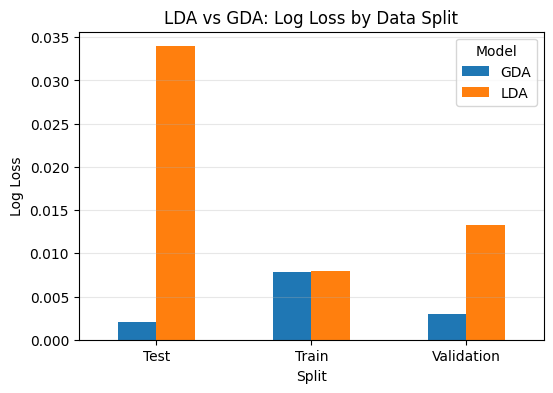

In [36]:
import matplotlib.pyplot as plt

pivot_loss = results_df.pivot(index="Split", columns="Model", values="Log Loss")

plt.figure(figsize=(6, 4))
pivot_loss.plot(kind="bar", ax=plt.gca())
plt.ylabel("Log Loss")
plt.title("LDA vs GDA: Log Loss by Data Split")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

**[Bias-variance Trade-off]**

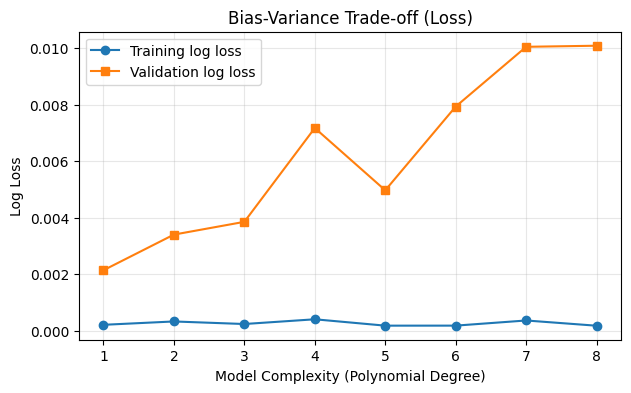

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

degrees = range(1, 9)

train_losses = []
val_losses = []
train_errors = []
val_errors = []

for d in degrees:
    clf = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(C=1e6, max_iter=5000))
    ])

    clf.fit(X_train, y_train)

    train_proba = clf.predict_proba(X_train)
    val_proba = clf.predict_proba(X_val)

    train_pred = clf.predict(X_train)
    val_pred = clf.predict(X_val)

    train_losses.append(log_loss(y_train, train_proba))
    val_losses.append(log_loss(y_val, val_proba))
    train_errors.append(1 - accuracy_score(y_train, train_pred))
    val_errors.append(1 - accuracy_score(y_val, val_pred))

plt.figure(figsize=(7, 4))
plt.plot(degrees, train_losses, marker='o', label='Training log loss')
plt.plot(degrees, val_losses, marker='s', label='Validation log loss')
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Log Loss")
plt.title("Bias-Variance Trade-off (Loss)")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### ■ **Evaluation Metrics**

* **Model Evaluation**
  * 방식
    * **Holdout**: 데이터를 한 번 나눠 train/test로 평가
    * **Cross Validation**: 데이터를 여러 조각으로 나눠 번갈아 검증

* **K-fold Cross Validation**
  * 평가 방식:
    1. 전체 데이터를 $K$개 fold로 나눔
    2. 1개 fold를 validation으로, 나머지 $K-1$개 fold로 학습
    3. 위 과정을 $K$번 반복
    4. $K$개 성능의 평균이 CV Score
  * **Repeated CV**: CV를 여러 번 반복해서 generalization error의 분산까지 추정
  * **Stratified CV**: 각 fold의 클래스 비율을 원본 데이터와 비슷하게 맞춤
  * **Nested CV**: 바깥 루프는 최종 평가, 안쪽 루프는 하이퍼파라미터 튜닝
  * **Leave-One-Out Cross Validation (LOOCV)**
    * $K=N$인 특수한 경우로, 샘플 하나만 validation으로 두고 나머지 전부로 학습
    * 데이터를 거의 다 학습에 활용할 수 있는 장점이 있으나, 계산량이 커질 수 있음
  
* **Regression**
  * **RMSE**: $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}$
  * **MAE**: $\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|$
  * **MAPE**: $\frac{1}{n}\sum_{i=1}^{n} \left|\frac{y_i-\hat y_i}{y_i}\right|\times 100$
  * **$R^2$**: $1-\frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2} = 1-\frac{\mathrm{SSE}}{\mathrm{SST}}$

* **Binary Classification**
  * **Accuracy**: $\frac{TP+TN}{TP+TN+FP+FN}$
  * **Precision**: $\frac{TP}{TP+FP}$
  * **Recall**: $\frac{TP}{TP+FN}$
  * **Specificity**: $\frac{TN}{TN+FP}$
  * **F1-score**: $2\cdot \frac{\mathrm{precision}\cdot \mathrm{recall}} {\mathrm{precision}+\mathrm{recall}}$

* **ROC Curve**
  * Binary classifier에서는 최종 예측을 위해 threshold $\tau$를 정함
    * Larger threshold: positive를 덜 예측 → recall 감소, specificity 증가
    * Smaller threshold: positive를 더 예측 → recall 증가, specificity 감소
  * ROC curve는 여러 가지 threshold에 대해 False Positive Rate (`1-specificity`), True Positive Rate (`recall`) 를 그린 곡선
  * 모델이 좋을수록 왼쪽 위에 가까운 곡선
  * **Area Under Curve (AUC)**: ROC 곡선을 하나의 숫자로 요약한 값 (1에 가까울수록 좋음)

* **Multiclass Classification**
  * **Multiclass Confusion matrix**: 각 클래스를 one-vs-rest처럼 positive로 놓고 precision, recall, F1을 클래스별로 계산
  * **Aggregated F1-score**
    * **Micro average**: 전체 TP/FP/FN를 합쳐 계산
    * **Weighted average**: 클래스별 F1을 support(표본 수)로 가중평균
    * **Macro average**: 클래스별 F1의 단순평균

---

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, StratifiedKFold, RepeatedStratifiedKFold, LeaveOneOut,
    GridSearchCV
)
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [39]:
# Multiclass iris
X_mc = X.copy()
y_mc = y.copy()

clf = LinearDiscriminantAnalysis()

**[Holdout vs. CV]**

In [40]:
# Holdout
X_tr, X_te, y_tr, y_te = train_test_split(
    X_mc, y_mc, test_size=0.3, random_state=42, stratify=y_mc
)

clf.fit(X_tr, y_tr)
holdout_acc = accuracy_score(y_te, clf.predict(X_te))

print(f"Holdout accuracy: {holdout_acc:.4f}")

# 5-fold Cross Validation
cv_scores = cross_val_score(clf, X_mc, y_mc, cv=5, scoring='accuracy')

print("5-fold CV scores:", np.round(cv_scores, 4))
print(f"5-fold CV mean ± std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Holdout accuracy: 0.9778
5-fold CV scores: [1.     1.     0.9667 0.9333 1.    ]
5-fold CV mean ± std: 0.9800 ± 0.0267


**[K-fold Cross Validation]**

In [41]:
cv_results = {}

# 1) KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kf = cross_val_score(clf, X_mc, y_mc, cv=kf, scoring='accuracy')
cv_results["KFold(5)"] = (scores_kf.mean(), scores_kf.std())

# 2) StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(clf, X_mc, y_mc, cv=skf, scoring='accuracy')
cv_results["StratifiedKFold(5)"] = (scores_skf.mean(), scores_skf.std())

# 3) RepeatedStratifiedKFold
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scores_rskf = cross_val_score(clf, X_mc, y_mc, cv=rskf, scoring='accuracy')
cv_results["RepeatedStratifiedKFold(5x10)"] = (scores_rskf.mean(), scores_rskf.std())

# 4) LOOCV
loo = LeaveOneOut()
scores_loo = cross_val_score(clf, X_mc, y_mc, cv=loo, scoring='accuracy')
cv_results["LOOCV"] = (scores_loo.mean(), scores_loo.std())

cv_df = pd.DataFrame(cv_results, index=["mean_accuracy", "std"]).T
display(cv_df)

,mean_accuracy,std
KFold(5),0.980000,0.016330
StratifiedKFold(5),0.973333,0.038873
RepeatedStratifiedKFold(5x10),0.978667,0.022862
LOOCV,0.980000,0.140000


In [42]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

param_grid = {"n_neighbors": [1, 3, 5, 7, 9]}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=inner_cv,
    scoring="accuracy"
)

nested_scores = cross_val_score(grid, X_mc, y_mc, cv=outer_cv, scoring="accuracy")

print("Nested CV scores:", np.round(nested_scores, 4))
print(f"Nested CV mean ± std: {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

Nested CV scores: [0.9667 1.     0.9333 1.     0.9333]
Nested CV mean ± std: 0.9667 ± 0.0298


**[Regression]**

In [43]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reg_data = load_diabetes()
X_reg = pd.DataFrame(reg_data.data, columns=reg_data.feature_names)
y_reg = pd.Series(reg_data.target, name="target")

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def r2_manual(y_true, y_pred):
    sse = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - sse / sst

In [44]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "Lasso(alpha=0.1)": Lasso(alpha=0.1, max_iter=10000)
}

reg_rows = []

for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)

    reg_rows.append({
        "Model": name,
        "RMSE": rmse(yr_test, pred),
        "MAE": mae(yr_test, pred),
        "MAPE(%)": mape(yr_test, pred),
        "R2": r2_manual(yr_test, pred)
    })

reg_results = pd.DataFrame(reg_rows)
display(reg_results)

,Model,RMSE,MAE,MAPE(%),R2
0,LinearRegression,53.120156,41.919378,36.671963,0.477290
1,Lasso(alpha=0.1),52.679836,41.938631,36.649067,0.485919


**[Binary classification]**

In [45]:
from sklearn.metrics import confusion_matrix

feature_cols = ['sepal length (cm)', 'sepal width (cm)']
mask = y.isin([0, 1])

X_bin = X.loc[mask, feature_cols].copy()
y_bin = y.loc[mask].copy()

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

def binary_metrics_from_cm(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "FPR": 1 - specificity,
        "TPR": recall
    }

In [46]:
binary_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Bayes Classifier (GaussianNB)": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "LDA": LinearDiscriminantAnalysis()
}

binary_rows = []

for name, model in binary_models.items():
    model.fit(Xb_train, yb_train)
    pred = model.predict(Xb_test)

    result = {"Model": name}
    result.update(binary_metrics_from_cm(yb_test, pred))
    binary_rows.append(result)

binary_results = pd.DataFrame(binary_rows)
display(binary_results)

,Model,Accuracy,Precision,Recall,Specificity,F1-score,FPR,TPR
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,0.0,1.0
1,Bayes Classifier (GaussianNB),1.0,1.0,1.0,1.0,1.0,0.0,1.0
2,KNN (k=5),1.0,1.0,1.0,1.0,1.0,0.0,1.0
3,LDA,1.0,1.0,1.0,1.0,1.0,0.0,1.0


**[ROC curve]**

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

# one model
model = LogisticRegression(max_iter=2000)
model.fit(Xb_train, yb_train)

proba = model.predict_proba(Xb_test)[:, 1]

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(yb_test, proba)
auc = roc_auc_score(yb_test, proba)

In [48]:
from sklearn.metrics import confusion_matrix

threshold_list = [0.2, 0.4, 0.5, 0.6, 0.8]
threshold_rows = []

for tau in threshold_list:
    pred_tau = (proba >= tau).astype(int)
    row = {"Threshold": tau}
    row.update(binary_metrics_from_cm(yb_test, pred_tau))
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,Threshold,Accuracy,Precision,Recall,Specificity,F1-score,FPR,TPR
0,0.2,0.900000,0.833333,1.000000,0.8,0.909091,0.2,1.000000
1,0.4,1.000000,1.000000,1.000000,1.0,1.000000,0.0,1.000000
2,0.5,1.000000,1.000000,1.000000,1.0,1.000000,0.0,1.000000
3,0.6,0.933333,1.000000,0.866667,1.0,0.928571,0.0,0.866667
4,0.8,0.833333,1.000000,0.666667,1.0,0.800000,0.0,0.666667


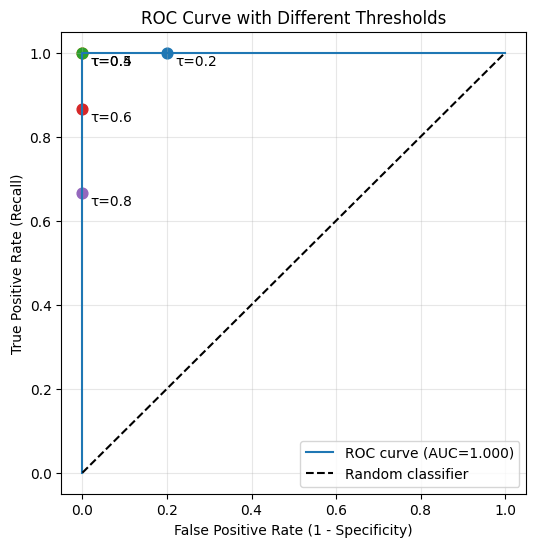

In [49]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")

for _, row in threshold_df.iterrows():
    plt.scatter(row["FPR"], row["TPR"], s=60)
    plt.text(row["FPR"] + 0.02, row["TPR"] - 0.03,
             f"τ={row['Threshold']:.1f}", fontsize=10)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Different Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

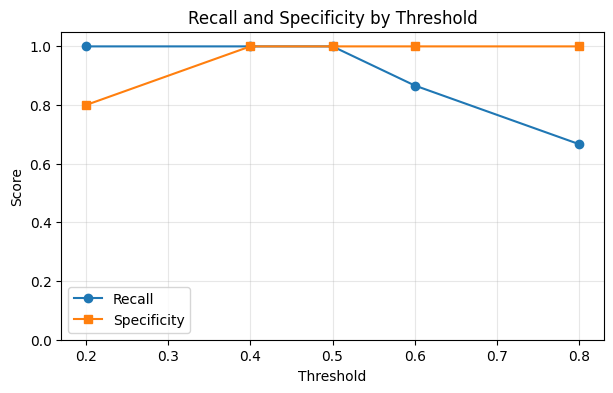

In [50]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker='o', label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Specificity"], marker='s', label="Specificity")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Recall and Specificity by Threshold")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**[Multiclass classification]**

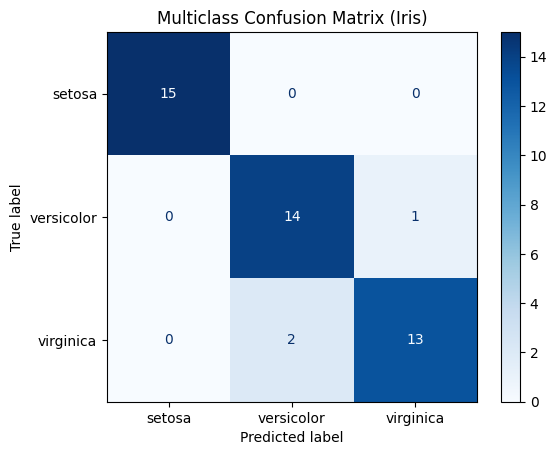

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [51]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mc, y_mc, test_size=0.3, random_state=42, stratify=y_mc
)

multi_model = LogisticRegression(max_iter=2000)
multi_model.fit(X_tr, y_tr)
y_pred_mc = multi_model.predict(X_te)

cm = confusion_matrix(y_te, y_pred_mc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues")
plt.title("Multiclass Confusion Matrix (Iris)")
plt.show()

print(classification_report(y_te, y_pred_mc, target_names=target_names))

In [52]:
multi_metric_df = pd.DataFrame([{
    "Accuracy": accuracy_score(y_te, y_pred_mc),
    "Micro F1": f1_score(y_te, y_pred_mc, average="micro"),
    "Macro F1": f1_score(y_te, y_pred_mc, average="macro"),
    "Weighted F1": f1_score(y_te, y_pred_mc, average="weighted")
}])

display(multi_metric_df)

,Accuracy,Micro F1,Macro F1,Weighted F1
0,0.933333,0.933333,0.933259,0.933259


-------

## **Exercise 2**

**[Dataset]**
  * [Credit Card Default Data](https://islp.readthedocs.io/en/latest/datasets/Default.html)
  * $X$:
    * 학생 여부 (student)
    * 월별 신용카드 잔액 (balance)
    * 연간 소득 (income)
  * $y$: 신용카드 연체 여부 (default)

In [53]:
!pip install ISLP
from ISLP import load_data

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=506c0d04184f6e56c44f0039ddac66beebf0a6d4f802cbbff050e44a46b14bda
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [54]:
df = load_data('Default')
display(df.head())

df['default'] = df.default.factorize()[0]
df['student'] = df.student.factorize()[0]

display(df.head())

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879


In [55]:
X = df[['student', 'balance', 'income']]
y = df['default']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 3)
y shape: (10000,)
